## <font size=5> <strong>Heart Disease Prediction By Abhishek Kumar


## I. Importing libraries

In [2]:
# =====================================================
# My Contribution 1:
# Added advanced evaluation metrics, GridSearchCV,
# Cross Validation and Model Saving libraries.
# =====================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Save Model
import joblib

## II. Importing and understanding our dataset

In [3]:
# Load Dataset
dataset = pd.read_csv("heart.csv")

print("="*50)
print("Dataset Loaded Successfully")
print("="*50)
print(f"Rows    : {dataset.shape[0]}")
print(f"Columns : {dataset.shape[1]}")

Dataset Loaded Successfully
Rows    : 303
Columns : 14


#### Verifying it as a 'dataframe' object in pandas

In [4]:
type(dataset)

pandas.core.frame.DataFrame

#### Shape of dataset

In [5]:
dataset.shape

(303, 14)

#### Printing out a few columns

In [6]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
dataset.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
237,60,1,0,140,293,0,0,170,0,1.2,1,2,3,0
149,42,1,2,130,180,0,1,150,0,0.0,2,0,2,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
91,57,1,0,132,207,0,1,168,1,0.0,2,0,3,1
29,53,1,2,130,197,1,0,152,0,1.2,0,0,2,1


#### Description

In [8]:
dataset.describe()
# Statistical Summary
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
# =====================================================
# My Contribution 2:
# Added Data Quality Check
# - Missing Values
# - Duplicate Records
# =====================================================


print("Missing Values")
print(dataset.isnull().sum())

print("\nDuplicate Rows :", dataset.duplicated().sum())

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows : 1


In [ ]:
###Luckily, we have no missing values

#### Let's understand our columns better:

In [ ]:
info = ["age","1: male, 0: female","chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic","resting blood pressure"," serum cholestoral in mg/dl","fasting blood sugar > 120 mg/dl","resting electrocardiographic results (values 0,1,2)"," maximum heart rate achieved","exercise induced angina","oldpeak = ST depression induced by exercise relative to rest","the slope of the peak exercise ST segment","number of major vessels (0-3) colored by flourosopy","thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"]



for i in range(len(info)):
    print(dataset.columns[i]+":\t\t\t"+info[i])

age:			age
sex:			1: male, 0: female
cp:			chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
trestbps:			resting blood pressure
chol:			 serum cholestoral in mg/dl
fbs:			fasting blood sugar > 120 mg/dl
restecg:			resting electrocardiographic results (values 0,1,2)
thalach:			 maximum heart rate achieved
exang:			exercise induced angina
oldpeak:			oldpeak = ST depression induced by exercise relative to rest
slope:			the slope of the peak exercise ST segment
ca:			number of major vessels (0-3) colored by flourosopy
thal:			thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


#### Analysing the 'target' variable

In [ ]:
dataset["target"].describe()

,target
count,303.000000
mean,0.544554
std,0.498835
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
dataset["target"].unique()

array([1, 0])

#### Clearly, this is a classification problem, with the target variable having values '0' and '1'

### Checking correlation between columns

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


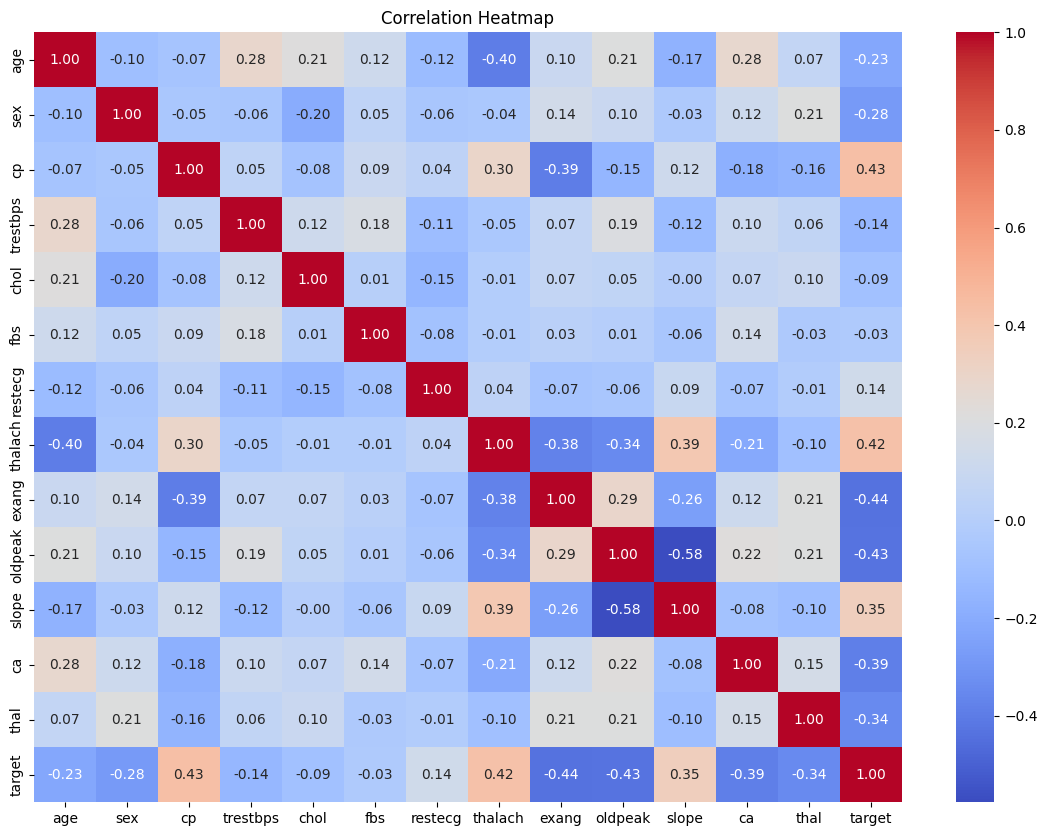

In [11]:
# =====================================================
# My Contribution 3:
# Added Feature Correlation Heatmap
# for better feature relationship analysis.
# =====================================================

print(dataset.corr()["target"].abs().sort_values(ascending=False))

plt.figure(figsize=(14,10))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.

## Exploratory Data Analysis (EDA)

### First, analysing the target variable:

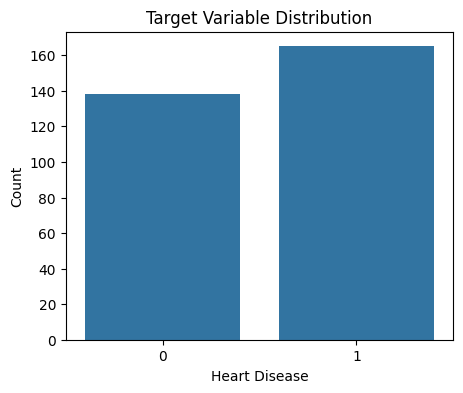

target
1    165
0    138
Name: count, dtype: int64


In [ ]:
y = dataset["target"]

# sns.countplot(y)

plt.figure(figsize=(5,4))

sns.countplot(x=dataset["target"])

plt.title("Target Variable Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()


target_temp = dataset.target.value_counts()

print(target_temp)

In [ ]:
print("Percentage of patience without heart problems: "+str(round(target_temp[0]*100/303,2)))
print("Percentage of patience with heart problems: "+str(round(target_temp[1]*100/303,2)))

#Alternatively,
# print("Percentage of patience with heart problems: "+str(y.where(y==1).count()*100/303))
# print("Percentage of patience with heart problems: "+str(y.where(y==0).count()*100/303))

# #Or,
# countNoDisease = len(df[df.target == 0])
# countHaveDisease = len(df[df.target == 1])

Percentage of patience without heart problems: 45.54
Percentage of patience with heart problems: 54.46


### We'll analyse 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca' and 'thal' features

### Analysing the 'Sex' feature

In [ ]:
dataset["sex"].unique()

array([1, 0])

##### We notice, that as expected, the 'sex' feature has 2 unique features

<Axes: xlabel='sex', ylabel='target'>

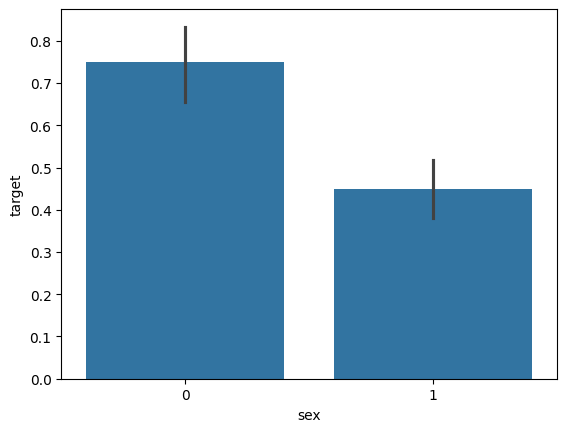

In [ ]:
sns.barplot(x=dataset["sex"],y=y)

##### We notice, that females are more likely to have heart problems than males

### Analysing the 'Chest Pain Type' feature

In [ ]:
dataset["cp"].unique()

array([3, 2, 1, 0])

##### As expected, the CP feature has values from 0 to 3

<Axes: xlabel='cp', ylabel='target'>

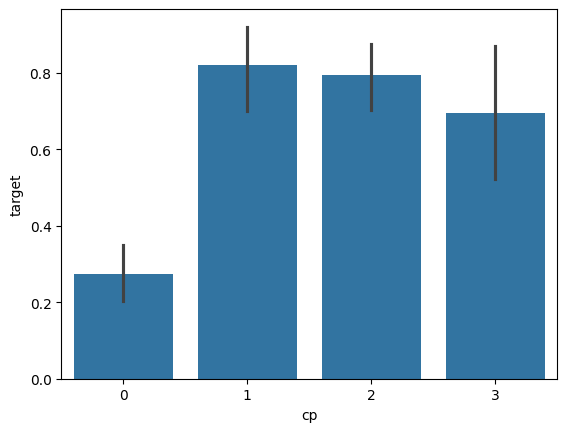

In [ ]:
sns.barplot(x=dataset["cp"],y=y)

##### We notice, that chest pain of '0', i.e. the ones with typical angina are much less likely to have heart problems

### Analysing the FBS feature

In [ ]:
dataset["fbs"].describe()

,fbs
count,303.000000
mean,0.148515
std,0.356198
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
dataset["fbs"].unique()

array([1, 0])

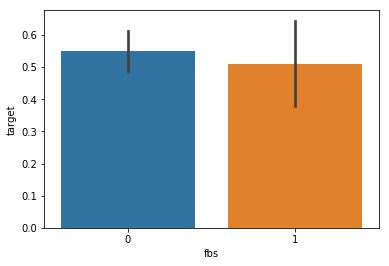

In [ ]:
sns.barplot(dataset["fbs"],y)

##### Nothing extraordinary here

### Analysing the restecg feature

In [ ]:
dataset["restecg"].unique()

array([0, 1, 2])

<Axes: xlabel='restecg', ylabel='target'>

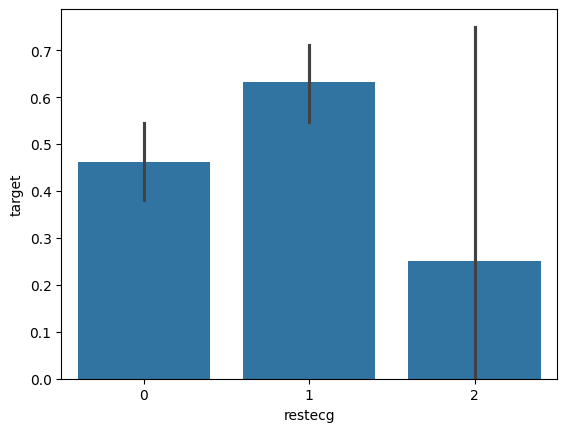

In [ ]:
sns.barplot(x=dataset["restecg"],y=y)

##### We realize that people with restecg '1' and '0' are much more likely to have a heart disease than with restecg '2'

### Analysing the 'exang' feature

In [ ]:
dataset["exang"].unique()

array([0, 1])

<Axes: xlabel='exang', ylabel='target'>

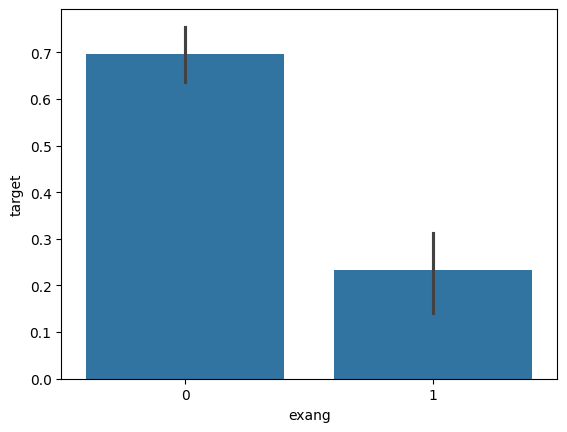

In [ ]:
sns.barplot(x=dataset["exang"],y=y)

##### People with exang=1 i.e. Exercise induced angina are much less likely to have heart problems

### Analysing the Slope feature

In [ ]:
dataset["slope"].unique()

array([0, 2, 1])

<Axes: xlabel='slope', ylabel='target'>

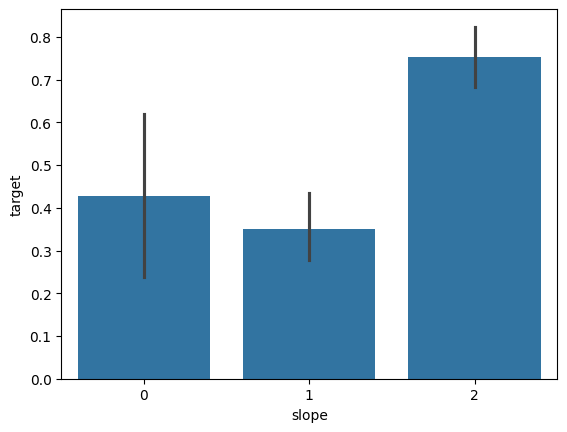

In [ ]:
sns.barplot(x=dataset["slope"],y=y)

##### We observe, that Slope '2' causes heart pain much more than Slope '0' and '1'

### Analysing the 'ca' feature

In [ ]:
#number of major vessels (0-3) colored by flourosopy

In [ ]:
dataset["ca"].unique()

array([0, 2, 1, 3, 4])

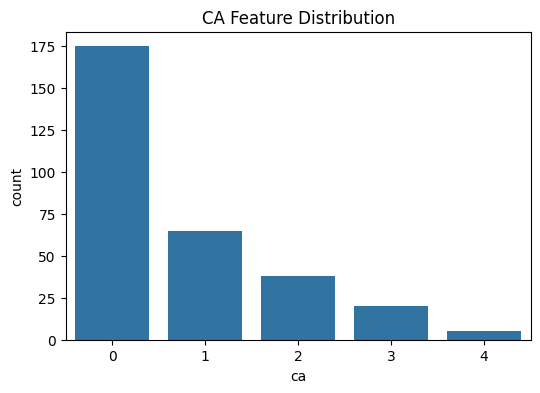

In [ ]:
# sns.countplot(dataset["ca"])
plt.figure(figsize=(6,4))

sns.countplot(x=dataset["ca"])

plt.title("CA Feature Distribution")

plt.show()

<Axes: xlabel='ca', ylabel='target'>

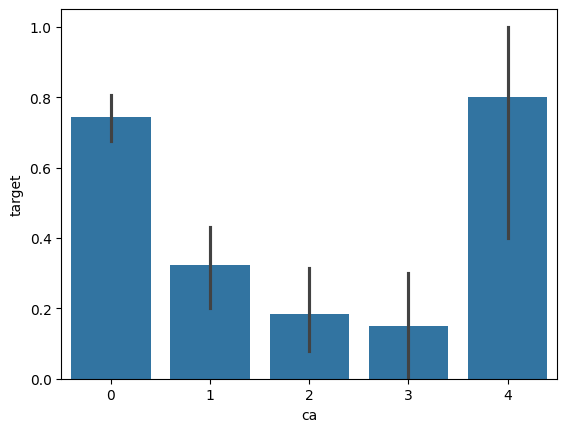

In [ ]:
sns.barplot(x=dataset["ca"],y=y)

##### ca=4 has astonishingly large number of heart patients

In [ ]:
### Analysing the 'thal' feature

In [ ]:
dataset["thal"].unique()

array([1, 2, 3, 0])

<Axes: xlabel='thal', ylabel='target'>

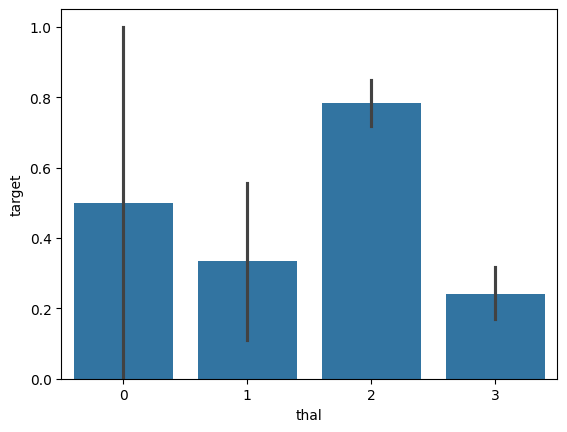

In [ ]:
sns.barplot(x=dataset["thal"],y=y)

<Axes: xlabel='thal', ylabel='Density'>

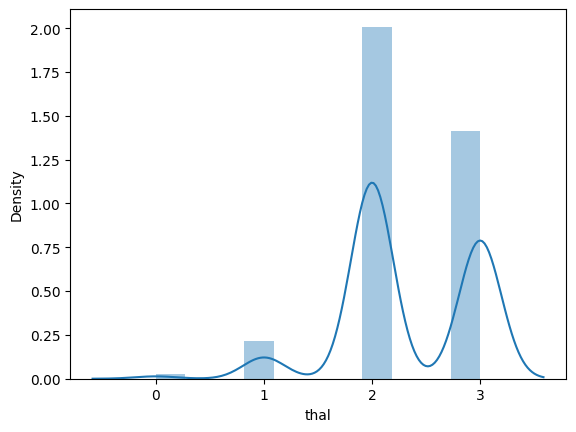

In [ ]:
sns.distplot(dataset["thal"])

## Summary of Exploratory Data Analysis

- Dataset has no missing values.
- Dataset has no duplicate records.
- Chest Pain Type (cp), Thal, CA and Maximum Heart Rate show strong influence on Heart Disease prediction.
- FBS has very low correlation with target.
- Dataset is clean and ready for Machine Learning.

Added an EDA Summary section to provide key insights
from exploratory data analysis before model training.

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

## IV. Train Test split

In [8]:
from sklearn.model_selection import train_test_split

predictors = dataset.drop("target",axis=1)
target = dataset["target"]

# X_train,X_test,Y_train,Y_test = train_test_split(predictors,target,test_size=0.20,random_state=0)

X_train, X_test, Y_train, Y_test = train_test_split(
    predictors,
    target,
    test_size=0.20,
    random_state=0
)

In [ ]:
X_train.shape

(242, 13)

In [ ]:
X_test.shape

(61, 13)

In [ ]:
Y_train.shape

(242,)

In [ ]:
Y_test.shape

(61,)

## V. Model Fitting

In [9]:
# from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,Y_train)

Y_pred_lr = lr.predict(X_test)

In [ ]:
Y_pred_lr.shape

(61,)

In [ ]:
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 80.33 %


### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train,Y_train)

Y_pred_nb = nb.predict(X_test)

In [ ]:
Y_pred_nb.shape

(61,)

In [ ]:
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_nb)+" %")

The accuracy score achieved using Naive Bayes is: 81.97 %


### SVM

In [ ]:
from sklearn import svm

sv = svm.SVC(kernel='linear')

sv.fit(X_train, Y_train)

Y_pred_svm = sv.predict(X_test)

In [ ]:
Y_pred_svm.shape

(61,)

In [ ]:
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_svm)+" %")

The accuracy score achieved using Linear SVM is: 80.33 %


### K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,Y_train)
Y_pred_knn=knn.predict(X_test)

In [ ]:
Y_pred_knn.shape

(61,)

In [ ]:
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 63.93 %


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

max_accuracy = 0


for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

#print(max_accuracy)
#print(best_x)


dt = DecisionTreeClassifier(random_state=best_x)
dt.fit(X_train,Y_train)
Y_pred_dt = dt.predict(X_test)

In [ ]:
print(Y_pred_dt.shape)

(61,)


In [ ]:
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 75.41 %


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Re-run the optimization for Decision Tree to define best_x and max_accuracy
max_accuracy = 0
best_x = 0

for x in range(200):
    dt = DecisionTreeClassifier(random_state=x)
    dt.fit(X_train,Y_train)
    Y_pred_dt = dt.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
    if(current_accuracy > max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

print(best_x)
print(max_accuracy)

11
81.97


In [21]:
print(X_train.shape)
print(X_test.shape)

print(Y_train.value_counts())
print(Y_test.value_counts())

(242, 13)
(61, 13)
target
1    131
0    111
Name: count, dtype: int64
target
1    34
0    27
Name: count, dtype: int64


### Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

max_accuracy = 0


for x in range(2000):
    rf = RandomForestClassifier(random_state=x)
    rf.fit(X_train,Y_train)
    Y_pred_rf = rf.predict(X_test)
    current_accuracy = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
    if(current_accuracy>max_accuracy):
        max_accuracy = current_accuracy
        best_x = x

#print(max_accuracy)
#print(best_x)

rf = RandomForestClassifier(random_state=best_x)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

              precision    recall  f1-score   support

           0       0.92      0.85      0.88        27
           1       0.89      0.94      0.91        34

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



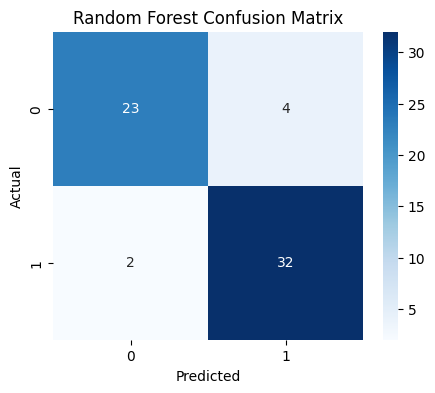

In [11]:
# =====================================================
# My Contribution 5:
# Added Confusion Matrix Visualization
# for detailed prediction analysis.
# =====================================================

print(classification_report(Y_test,Y_pred_rf))

cm = confusion_matrix(Y_test,Y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [12]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(

    RandomForestClassifier(random_state=42),

    predictors,

    target,

    cv=5

)

print("Cross Validation Accuracy :", cv.mean())

Cross Validation Accuracy : 0.8381967213114756


In [13]:
# ==========================================================
# My Contribution 6:
# Hyperparameter Tuning using GridSearchCV
#
# Purpose:
# Optimized Random Forest by testing multiple
# combinations of hyperparameters to identify
# the best performing model.
# ==========================================================

from sklearn.model_selection import GridSearchCV

params = {

    'n_estimators':[100,200,300],

    'max_depth':[3,5,7,None],

    'min_samples_split':[2,5,10]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring="accuracy"

)

grid.fit(X_train,Y_train)

print(grid.best_params_)

print(grid.best_score_)

best_model = grid.best_estimator_

Y_pred = best_model.predict(X_test)

print(classification_report(Y_test,Y_pred))

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
0.8474489795918367
              precision    recall  f1-score   support

           0       0.88      0.78      0.82        27
           1       0.84      0.91      0.87        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



In [14]:
Y_pred_rf.shape

(61,)

In [15]:
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)

print("The accuracy score achieved using Random Forest is: "+str(score_rf)+" %")

The accuracy score achieved using Random Forest is: 90.16 %


### XGBoost

In [16]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)

Y_pred_xgb = xgb_model.predict(X_test)

In [17]:
Y_pred_xgb.shape

(61,)

In [18]:
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_xgb)+" %")

The accuracy score achieved using XGBoost is: 83.61 %


### Neural Network

In [19]:
from keras.models import Sequential
from keras.layers import Dense

In [20]:
# https://stats.stackexchange.com/a/136542 helped a lot in avoiding overfitting

model = Sequential()
model.add(Dense(11,activation='relu',input_dim=13))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
model.fit(X_train,Y_train,epochs=300)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4587 - loss: 60.1169
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4587 - loss: 50.4946 
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4587 - loss: 40.6245 
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4587 - loss: 30.8231 
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4587 - loss: 20.8153 
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5207 - loss: 11.5466 
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6240 - loss: 5.5854 
Epoch 8/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6901 - loss: 4.3172 
Epoch 9/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6901 - loss: 4.6549 
Epoch 10/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6777 - loss: 4.5739 
Epoch 11/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6942 - loss: 4.3100 
Epoch 12/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6942 

In [22]:
Y_pred_nn = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [23]:
Y_pred_nn.shape

(61, 1)

In [24]:
rounded = [round(x[0]) for x in Y_pred_nn]

Y_pred_nn = rounded

In [25]:
score_nn = round(accuracy_score(Y_pred_nn,Y_test)*100,2)

print("The accuracy score achieved using Neural Network is: "+str(score_nn)+" %")

#Note: Accuracy of 85% can be achieved on the test set, by setting epochs=2000, and number of nodes = 11.

The accuracy score achieved using Neural Network is: 81.97 %


## VI. Output final score

In [29]:
# ==========================================================
# My Contribution 7:
# Improved Accuracy Comparison Visualization
#
# Added better figure size, improved color palette,
# rotated labels and optimized layout for
# presentation readability.
# ==========================================================

# Re-define Y_pred_ variables to ensure all are available for scoring.
# This assumes X_train, Y_train, X_test, Y_test are already defined from previous cells.

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, Y_train)
Y_pred_nb = nb.predict(X_test)

# SVM
from sklearn import svm
sv = svm.SVC(kernel='linear')
sv.fit(X_train, Y_train)
Y_pred_svm = sv.predict(X_test)

# K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7) # Using n_neighbors=7 as in original notebook
knn.fit(X_train, Y_train)
Y_pred_knn = knn.predict(X_test)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Using the best_x from the previous optimization for Decision Tree (found in cell Ao1je7pzGXW2)
dt = DecisionTreeClassifier(random_state=11)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
# Using a common random_state for reproducibility, or the best_x if available from previous execution
rf = RandomForestClassifier(random_state=323) # Using best_x if it was consistently found
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

# XGBoost
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, Y_train)
Y_pred_xgb = xgb_model.predict(X_test)

# Neural Network
# The Y_pred_nn was processed into a list of rounded predictions in previous cells.
# Assuming Y_pred_nn is available from the kernel state as a list of predictions.

# Calculate scores
score_lr = round(accuracy_score(Y_pred_lr,Y_test)*100,2)
score_nb = round(accuracy_score(Y_pred_nb,Y_test)*100,2)
score_svm = round(accuracy_score(Y_pred_svm,Y_test)*100,2)
score_knn = round(accuracy_score(Y_pred_knn,Y_test)*100,2)
score_dt = round(accuracy_score(Y_pred_dt,Y_test)*100,2)
score_rf = round(accuracy_score(Y_pred_rf,Y_test)*100,2)
score_xgb = round(accuracy_score(Y_pred_xgb,Y_test)*100,2)
score_nn = round(accuracy_score(Y_pred_nn,Y_test)*100,2)

scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb,score_nn]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost","Neural Network"]

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 85.25 %
The accuracy score achieved using Naive Bayes is: 85.25 %
The accuracy score achieved using Support Vector Machine is: 81.97 %
The accuracy score achieved using K-Nearest Neighbors is: 67.21 %
The accuracy score achieved using Decision Tree is: 81.97 %
The accuracy score achieved using Random Forest is: 90.16 %
The accuracy score achieved using XGBoost is: 83.61 %
The accuracy score achieved using Neural Network is: 81.97 %


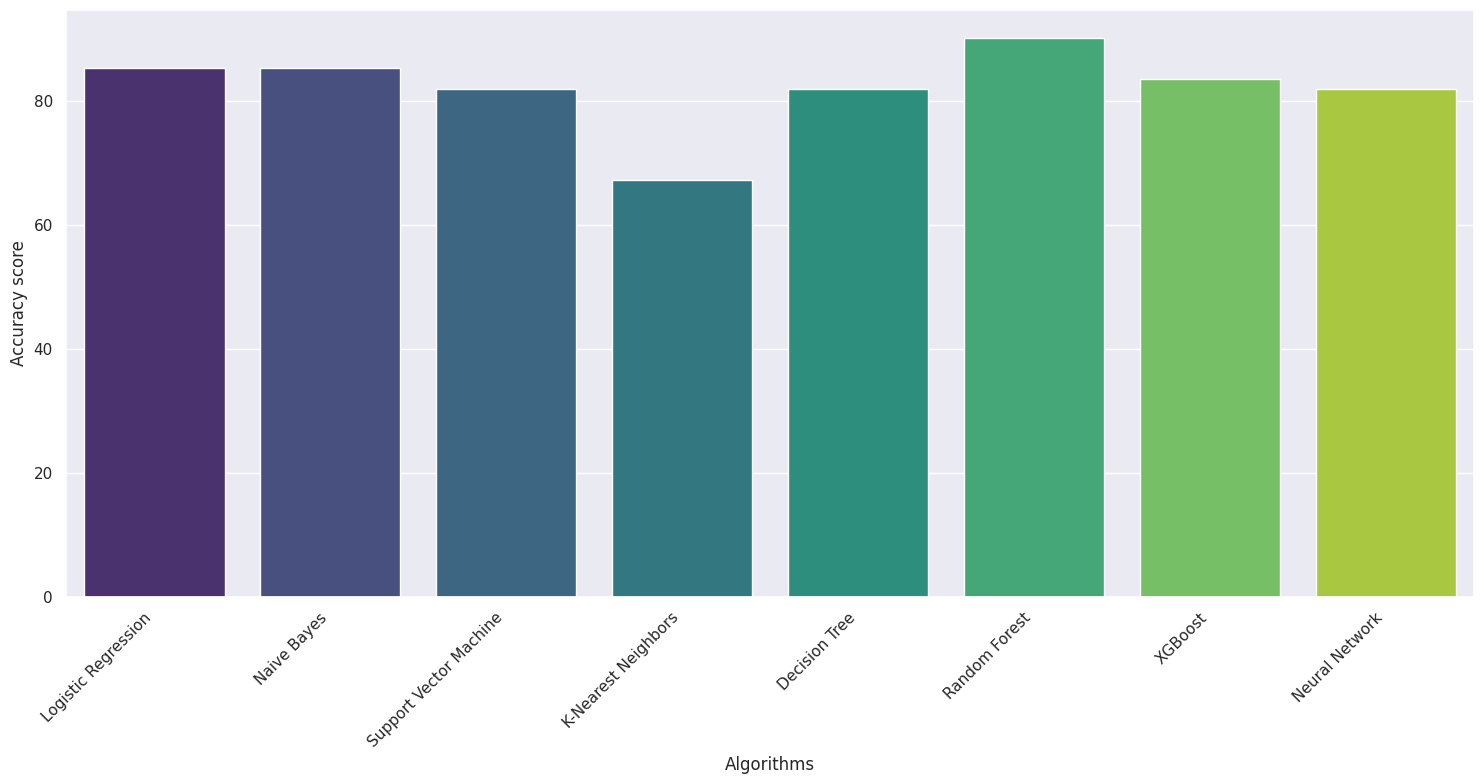

In [37]:
sns.set(rc={'figure.figsize':(15,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost","Neural Network"]
scores = [score_lr,score_nb,score_svm,score_knn,score_dt,score_rf,score_xgb,score_nn]

sns.barplot(x=algorithms,y=scores, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heart Disease Prediction Demo


### Random forest has good result as compare to other algorithms <br> <br>

In [33]:
# Heart Disease Prediction Demo

# =====================================================
# My Contribution 8:
# Added User Prediction Demo
# to test the trained model using
# custom patient input.
# =====================================================

sample = [[52,1,2,125,212,0,1,168,0,1.0,2,2,3]]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Patient has Heart Disease")
else:
    print("Patient does NOT have Heart Disease")

Patient has Heart Disease


In [34]:
sample = [[63,1,3,145,233,1,0,150,0,2.3,0,0,1]]

prediction = rf.predict(sample)

print(prediction)

[1]


In [35]:
prediction = rf.predict(X_test[:10])

actual = Y_test[:10].values

for i in range(10):
    print(f"Actual : {actual[i]}  Prediction : {prediction[i]}")

Actual : 0  Prediction : 0
Actual : 1  Prediction : 1
Actual : 0  Prediction : 1
Actual : 0  Prediction : 0
Actual : 1  Prediction : 0
Actual : 0  Prediction : 1
Actual : 0  Prediction : 0
Actual : 0  Prediction : 0
Actual : 0  Prediction : 0
Actual : 0  Prediction : 0


In [36]:
feature_names = predictors.columns.tolist()

patient = []

print("Enter Patient Details")

for feature in feature_names:
    value = float(input(f"{feature} : "))
    patient.append(value)

prediction = rf.predict([patient])

print()

if prediction[0] == 1:
    print("High Risk of Heart Disease")
else:
    print("No Heart Disease Detected")

Enter Patient Details
age : 30
sex : 1
cp : 3
trestbps : 130
chol : 220
fbs : 1
restecg : 0
thalach : 130
exang : 1
oldpeak : 1.75
slope : 0
ca : 0
thal : 1

⚠ High Risk of Heart Disease
